<a href="https://colab.research.google.com/github/jonesgoebel/ufpel-pdi-2026-2-M2/blob/main/LAB3_5_Alargamento_Contraste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB3.5 — Alargamento de Contraste e Histogramas

Disciplina: **Processamento Digital de Imagens (PDI)** – UFPel   

Este notebook introduz e pratica os conceitos de **alargamento de contraste** e **equalização de histogramas** em imagens digitais.  

---

## Objetivos  
- Carregar e visualizar imagens em escala de cinza.  
- Calcular e interpretar **histogramas** de intensidade.  
- Implementar o **alargamento de contraste** linear, mapeando a faixa de intensidade original para todo o intervalo [0, 255].  
- Utilizar função de **equalização de histograma**.  
- Comparar os efeitos visuais e nos histogramas das diferentes transformações.
- Implementar o realce de contraste com **transformação de potência**.  

---

## 1) Bibliotecas úteis
Se estiver no Colab, rode a célula de instalação uma única vez.

In [ ]:
# Se necessário no Colab, descomente a linha abaixo:
#!pip -q install numpy matplotlib scikit-image imageio

In [ ]:
# %% setup - Importações e funções utilitárias
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2 as cv
from pathlib import Path

In [ ]:
def converte_cinza(figura):
    """
    Recebe o caminho de uma imagem BMP, converte para escala de cinza, salva a imagem, retorna a imagem.
    """
    path = Path(figura)
    img = Image.open(figura).convert('L')

    # Salva a imagem convertida
    caminho_saida = path.with_name(f"{path.stem}_cinza{path.suffix}")
    img.save(caminho_saida)

    # Retorna o objeto Image
    return img

## 2) Abrindo uma imagem e apresentando seu histograma
Vamos criar uma função **Python** que:
- **Receba** o caminho de uma imagem BMP em escala de cinza
- **Apresente** a imagem e o histograma da imagem.

Nome da função: `histograma_imagem(figura)`.

In [ ]:
def mostra_img_histograma(figura):
    """
    exibe a imagem e apresenta seu histograma (lado a lado).
    """
    img_array = np.array(figura).flatten()

    # Cria figura com 2 colunas
    plt.figure(figsize=(12,5))

    # Mostra a imagem
    plt.subplot(1,2,1)
    plt.imshow(figura, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Imagem")
    plt.axis('on')

    # Mostra o histograma
    plt.subplot(1,2,2)
    plt.hist(img_array, bins=100, range=(0,255), color='black')
    plt.title(f"Histograma")
    plt.xlabel("Intensidade (0–255)")
    plt.ylabel("Frequência de pixels")

    plt.tight_layout()
    plt.show()

Código que chama essa função.

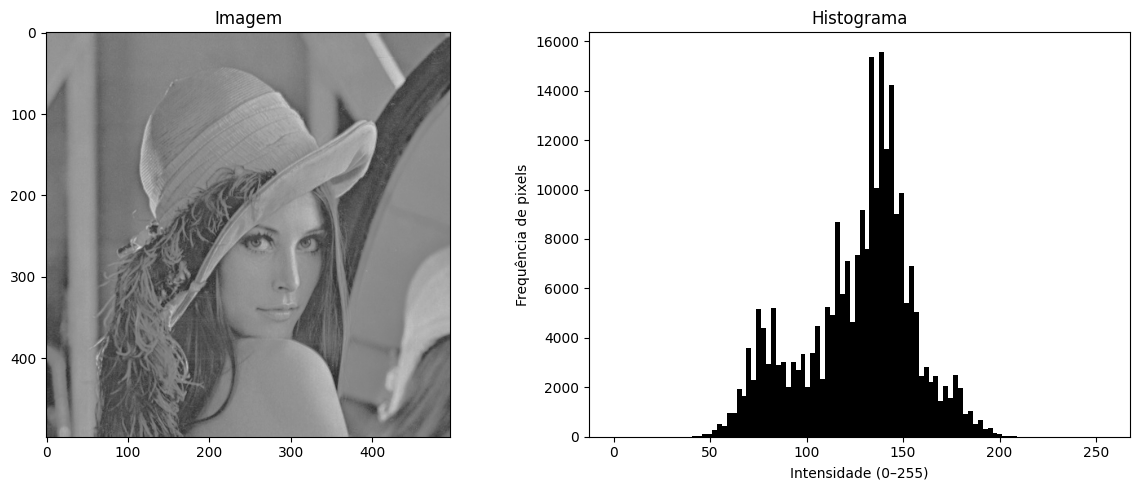

In [ ]:
img_cinza = converte_cinza('lena_lc.bmp')
mostra_img_histograma(img_cinza)

## 2)  🖼️ Tarefa 1 — Função de Alargamento de Contraste

Implemente uma função em **Python** que:  

1. **Receba** uma imagem BMP (`figura`) em escala de cinza.  
2. **Calcule** os valores mínimo (`imin`) e máximo (`imax`) de intensidade presentes na imagem.
3. **Reescale** (normalize) todos os pixels para que `imin` seja mapeado para `0` e `imax` seja mapeado para `255`.

⚠️ Caso `imin == imax` (imagem com intensidade constante), a função deve simplesmente retornar uma imagem preta (todos os valores 0).  

---

### Nome sugerido da função:
```python
def contraste(figura):
    ...
```

4. Exibir a imagem original em escala de cinza e seu histograma.
5. Exibir a imagem com contraste alargado e seu histograma.

In [ ]:
#COLOQUE SEU CÓDIGO AQUI


In [ ]:
#COLOQUE SEU CÓDIGO AQUI


## 2) 📝 Tarefa 2 — Equalização de Histograma (CLAHE)

Nesta atividade, você irá aplicar uma técnica de **equalização de histograma** chamada CLAHE (Contrast Limited Adaptive Histogram Equalization), implementada e disponível na biblioteca OpenCV (cv2, importada neste notebook). O CLAHE melhora o contraste de imagens em escala de cinza, atingindo resultados melhores que o simples alargamento de contraste global.


### Passos a seguir:

1. **Carregue uma imagem em tons de cinza**  
   - Use a função `converte_cinza` (ou equivalente) para garantir que a imagem esteja no formato escala de cinza.  
   - Exemplo:  
     ```python
     img_cinza = converte_cinza("lena_lc.bmp")
     ```

2. **Aplique o alargamento de contraste que implementamos antes (apenas para comparar)**  
   - Use a função `contraste` já implementada para gerar uma nova versão da imagem com contraste expandido (como fizemos no exercício anterior).  
   - Exemplo:  
     ```python
     img_contraste = contraste(img_cinza)
     ```

3. **Visualize a imagem original e a imagem com contraste alargado, como já fizemos na tarefa anterior**  
   - Utilize a função `mostra_img_histograma` para exibir a imagem **e seu histograma** lado a lado.  
   - Exemplo:  
     ```python
     mostra_img_histograma(img_cinza)
     mostra_img_histograma(img_contraste)
     ```

4. **Agora aplique CLAHE (Contrast Limited Adaptive Histogram Equalization)**  
   - Utilize o OpenCV parar criar um objeto CLAHE e depois gere a imagem nova:  
     ```python
     claheObj = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
     img_clahe = claheObj.apply(img_cinza_np)
     ```
   - Compare os resultados (imagem + histograma) com o alargamento global.
   - Varie os valores de clipLimit e tileGridSize para avaliar os efeitos do CLAHE.
   - Mostre a imagem resultante e o histograma lado a lado usando `matplotlib`.
---